# Echo energy only optimisation Scenario example
An example of defining an echo netset that does not need a network model and which can have an arbitrary number of sites to be optimised.

Each netset has psuedo random assets (battery, evs, pv) at each components.

Features yet to come:
- export of results to data frame (currently have to query the list of dictionaries at netset.networks for most things
- power available of V2G chargers to provide grid services

First we will define the percentages of DER penetration we want so that when we define the sites we can add the appropriate amounts

In [1]:
pv_percent = 0.1  # percentage of sites with PV (0-1)
bat_percent = 0.01  # percentage of sites with battery (0-1)
ev_percent = 0.01  # percentage of sites with evs (0-1)
ev_mean = 1  # mean number of evs per household

Create a netset object of class NetworkSet from echo_builder. The description string is used to keep details such as percentages of DER.

In [3]:
import echo.echo_builder as eb

description = 'test energy only network set of 10 sites with {}% pv, {}% batteries, {}% evs'.format(pv_percent * 100,
                                                                                                   bat_percent * 100,
                                                                                                   ev_percent * 100)
netset = eb.NetworkSet(name='default_name', description=description)

Create component information to add to the network set
First we will define some default assets and then these will be randomly scaled or assigned as appropriate to each components.
See the notebook ‘site_optimisation_example’ for documentation on how a components should be defined

In [4]:
import numpy as np

days = 1  # number of days we wish to optimise

time_periods = 96 * days
interval_duration = 15

# Define data

# define load profile
load_profile = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 2.2, 2.15, 2.02, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 2.05, 2.19] * days)

# define a pv profile
pv_profile = -1 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] * days)

# Define generic battery parameters
battery_params = {'max_capacity': 15., 'depth_of_discharge_limit': 0,
                  'charging_power_limit': 1.25, 'discharging_power_limit': -1.25,
                  'charging_efficiency': 1., 'discharging_efficiency': 1.,
                  'initial_state_of_charge': 0}

# define generic ev profiles
# V2G vehicle
v2g_available = np.array(([1] * 24 + [0] * 24 + [1] * 24 + [0] * 24) * days)  # binary for when its available to charge
v2g_usage = np.array(
    ([0.0] * 24 + [0.5] * 24 + [0.0] * 24 + [1.0] * 24) * days)  # energy usage on trip at each time period
v2g = {'name': 'v2g', 'available': v2g_available, 'usage': v2g_usage, 'max_capacity': 40.,
       'depth_of_discharge_limit': 0,
       'charging_power_limit': 10., 'discharging_power_limit': -10, 'charging_efficiency': 1,
       'discharging_efficiency': 1, 'initial_state_of_charge': 0.0, 'charge_mode': 'V2G',
       'interval_duration': interval_duration}

# second vehicle is V1G
v1g_available = np.array(([1] * 10 + [0] * 10 + [1] * 28 + [0] * 48) * days)
v1g_usage = np.array(([0.0] * 10 + [0.4] * 10 + [0.0] * 28 + [0.5] * 48) * days)
v1g = {'name': 'v1g', 'available': v1g_available, 'usage': v1g_usage, 'max_capacity': 40.,
       'depth_of_discharge_limit': 0,
       'charging_power_limit': 10., 'discharging_power_limit': 0, 'charging_efficiency': 1,
       'discharging_efficiency': 1, 'initial_state_of_charge': 0.0, 'charge_mode': 'V1G',
       'interval_duration': interval_duration}

# third vehicle is V0G
v0g = {'name': 'v0g', 'available': v2g_available, 'usage': v2g_usage, 'max_capacity': 40.,
       'depth_of_discharge_limit': 0,
       'charging_power_limit': 10., 'discharging_power_limit': -10, 'charging_efficiency': 1,
       'discharging_efficiency': 1, 'initial_state_of_charge': 0.0, 'charge_mode': 'V0G',
       'interval_duration': interval_duration}

# fourth vehicle is V0G with tod charging
tod_charging = np.ones(v1g_available.shape)
tod_charging[20:30] = 0.  # we dont want to charge in the 20-30 time intervals
v0g_tod = {'name': 'v0g_tod',
           'available': v1g_available,
           'usage': v1g_usage,
           'max_capacity': 40.,
           'depth_of_discharge_limit': 0,
           'charging_power_limit': 10.,
           'discharging_power_limit': -10,
           'charging_efficiency': 1,
           'discharging_efficiency': 1,
           'initial_state_of_charge': 0.0,
           'charge_mode': 'V0G',
           'tod_charging': tod_charging,
           'interval_duration': interval_duration}


# Generate the psuedo random components data and store in a list of dicts

In [5]:
num_sites = 10  # 10 sites

has_battery = np.random.rand(num_sites, ) > (1 - bat_percent)
has_solar = np.random.rand(num_sites, ) > (1 - pv_percent)
has_ev = np.random.rand(num_sites, ) > (1 - ev_percent)
num_evs = has_ev.astype(int) * np.random.poisson(ev_mean, (num_sites,))
names = ['site_{}'.format(i) for i in range(num_sites)]

In [6]:

sites = []
for i in range(num_sites):
    components = {}
    edges = {}

    """ If everything was pydantic classes, it might look more like this:
    components['grid'] = FlexNode(id='grid', 'units'='kW', ports=['downstream']).
    and this way we could check at creation that things have valid units/types/numbers of ports/parameter values.

    Might also look like this: OurMESModel.add_component = Component(FlexNode(....))

    But let's wait for MES progress first.
    """

    components['grid'] = {'id': 'grid', 'type': 'flex', 'units': 'kW', 'ports': ['downstream']}

    components['cp'] = {'id': 'cp', 'type': 'tellegen', 'units': 'kW', 'ports': ['cp'],
                        'parameters': {'cp': {'max_import': None, 'max_export': None, 'slack': False}}}

    edges['grid_cp'] = {'nodes': ('grid', 'cp'), 'ports': ('downstream', 'cp'), 'res': 'elec'}

    if has_battery[i]:
        components['battery'] = {'id': 'battery', 'type': 'battery', 'ports': ['battery'], 'parameters': battery_params.copy()}

        # add a port to the cp component to connect battery to
        components['cp']['ports'].append('battery')
        # define the edge
        edges['bess_cp'] = {'nodes': ('battery', 'cp'), 'ports': ('battery', 'battery'), 'res': 'elec'}

    if has_solar[i]:
        pv = pv_profile * (0.5 + np.random.rand())  # random scale applied to pv load
        components['solar'] = {'id': 'solar', 'type': 'solar', 'ports': ['solar'], 'data': pv, 'parameters': {'curtailable': False}}
        # add a port to the cp component to connect solar to
        components['cp']['ports'].append('solar')
        # define the edge
        edges['solar_cp'] = {'nodes': ('solar', 'cp'), 'ports': ('solar', 'solar'), 'res': 'elec'}

    l = load_profile * (0.5 + np.random.rand())  # random scale between 0.5 and 1.5 applied to load
    components['load'] = {'id': 'load', 'type': 'load', 'units': 'kW', 'ports': ['load'], 'data': l}
    # add a port to the cp component to connect the load to
    components['cp']['ports'].append('load')
    # define the edge
    edges['load_cp'] = {'nodes': ('load', 'cp'), 'ports': ('load', 'load'), 'res': 'elec'}

    if has_ev[i]:
        for k in range(num_evs[i]):
            which_ev = np.random.rand()
            if which_ev > 0.75:
                tmp = v2g.copy()
            elif which_ev > 0.5:
                tmp = v1g.copy()
            elif which_ev > 0.25:
                tmp = v0g.copy()
            else:
                tmp = v0g_tod.copy()

            tmp['name'] = tmp['name'] + '_' + str(k)
            ev_name = tmp['name']
            components[ev_name] = {'id': ev_name, 'type': 'ev', 'ports': ['ev_cp'], 'parameters': tmp}
            # add a port to the cp component to connect the ev to
            components['cp']['ports'].append(ev_name)
            # define the edge
            edges[ev_name + '_cp'] = {'nodes': (ev_name, 'cp'), 'ports': ('ev_cp', ev_name), 'res': 'elec'}


    # define an objective
    objective = {
        'import_tariff': {
            'type': 'import_tariff',
            'prices': np.array(([0.1] * 28 + [0.3] * 8 + [0.2] * 32 + [0.3] * 16 + [0.1] * 12) * days),
            'component': {'node': 'cp', 'port': 'cp'}
        },
        'export_tariff': {
            'type': 'export_tariff',
            'prices': np.array(([0.1] * 96) * days),
            'component': {'node': 'cp', 'port': 'cp'}
        }
    }

    # Construct the site. It has a name, components, edges, and objectives - todo whether the objective should go here, but it is convenient for now
    site = {'name': 'site_'+str(i),
            'components': components,
            'edges': edges,
            'objective': objective}
    # add this site to our list of sites
    sites.append(site)

Add sites to our network set

In [7]:
netset.add_networks_from_list(sites)

# Specify the interval duration and time period for our network set
netset.interval_duration = interval_duration
netset.time_periods = time_periods

Optimise all sites in the netset
This will perform any required optimisation and aggregate the total load on the grid.
The output processing_errors will be False if a components was able to be processed and True if it could not be.

In [8]:
import time

t1 = time.time()
processing_errors = netset.optimise_network_set()
t2 = time.time()
print('\n')
print('Time to optimise all sites for {} intervals of {} minutes was {} minutes'.format(time_periods, interval_duration,
                                                                                        np.round((t2 - t1) / 60), 1))
print('Number of sites failed to be processed was ', np.array(processing_errors).sum(), '/', num_sites)

Optimising sites: 100%|██████████| 10/10 [00:00<00:00, 13.77it/s]



Time to optimise all sites for 96 intervals of 15 minutes was 0.0 minutes
Number of sites failed to be processed was  0 / 10


Having a look at some summary results
A look at two results for each components:
the aggregate load on the grid from that components
the violation (if any) of the import and exprot constraint from the grid

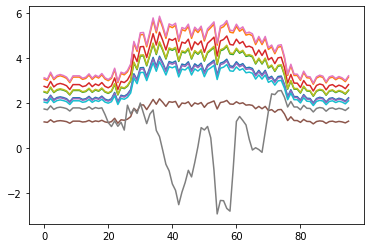

Max export violation was 0.0
Max import violation was 0.0


<Figure size 432x288 with 0 Axes>

In [9]:
export_violations = []
import_violations = []
aggregate_loads = []
for network in netset.results:
    export_violations.append(network['cp']['cp']['export_violation'])
    import_violations.append(network['cp']['cp']['import_violation'])
    aggregate_loads.append(network['cp']['cp']['port_val'])

import matplotlib.pyplot as plt

# plot the first 100 aggreate loads
for ag_load in aggregate_loads:
    plt.plot(ag_load)
plt.show()


print('Max export violation was {}'.format(np.array(export_violations).max()))
print('Max import violation was {}'.format(np.array(import_violations).max()))

plt.tight_layout()
plt.show()

Export values from a particular node and port to dataframe and save

In [ ]:

site_loads_df = netset.to_df(node='cp', port='cp')
site_loads_df.to_csv('../../data/dummy_netset_loads.csv')